# **ĐỒ ÁN 2: DATA FITTING VÀ PHƯƠNG PHÁP OLS - PHẦN 1: LÝ THUYẾT VÀ MINH HỌA**

Ở trong demo Notebook của phần này nhóm em tập trung chạy thử và nêu cơ sở lí thuyết các hàm. Vì testcase hoàn chỉnh dài nên em bỏ trực tiếp vào filecode của các hàm ạ

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

from helper_function import add_intercept
from ols_implementation import (
    ols_fit, 
    hat_matrix, 
    model_metrics, 
    coef_inference, 
    calculate_vif
)
from ridge_lasso import ridge_fit, plot_ridge_trace
from residual_analysis import residual_plots
from cross_validation import kfold_cv

np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 7)
sns.set_style("whitegrid")

### **Mục 1: Hàm ols_fit(X, y)**

Trong mô hình hồi quy tuyến tính $y = X\beta + \epsilon$, nghiệm chuẩn OLS được xác định bằng cách cực tiểu hóa tổng bình phương phần dư ($RSS$). Công thức nghiệm đóng là:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$

Ước lượng phương sai của nhiễu $\hat{\sigma}^2$ được tính bằng:
$$\hat{\sigma}^2 = \frac{RSS}{n - p - 1} = \frac{(y - X\hat{\beta})^T (y - X\hat{\beta})}{n - p - 1}$$
trong đó $n$ là số mẫu và $p$ là số biến độc lập (không tính intercept).

In [5]:
n, p = 100, 3
X = np.random.randn(n, p)
true_beta = np.array([2.5, 1.2, -0.5, 0.8])
y = true_beta[0] + X @ true_beta[1:] + np.random.normal(0, 0.5, n)

beta_hat, sigma2_hat = ols_fit(X.tolist(), y.tolist())

model_sklearn = LinearRegression().fit(X, y)
beta_sklearn = np.array([model_sklearn.intercept_] + list(model_sklearn.coef_))

np.testing.assert_allclose(beta_hat, beta_sklearn, rtol=1e-5)

print("Hệ số beta ước lượng (Manual):", beta_hat)
print("Hệ số beta (Scikit-learn):", beta_sklearn)
print("Ước lượng phương sai nhiễu:", sigma2_hat)

Hệ số beta ước lượng (Manual): [2.5564311456858584, 1.1611683569080302, -0.5249817753601957, 0.7462033429169873]
Hệ số beta (Scikit-learn): [ 2.55643115  1.16116836 -0.52498178  0.74620334]
Ước lượng phương sai nhiễu: 0.19707377268146395


### **Mục 2: Hàm hat_matrix(X)**

Ma trận hình mũ (Hat Matrix) $H$ ánh xạ vector quan sát $y$ thành vector dự báo $\hat{y}$:
$$\hat{y} = Hy = X(X^T X)^{-1} X^T y$$
Do đó: $H = X(X^T X)^{-1} X^T$.

Tính chất quan trọng của Hat Matrix là tính lũy đẳng (Idempotent):
$$H^2 = H \times H = H$$

In [6]:
H, is_idempotent = hat_matrix(X.tolist())

H_np = np.array(H)
H_squared = H_np @ H_np

print("Kiểm tra tính lũy đẳng (H^2 - H == 0):", np.allclose(H_squared, H_np))
print("Kết quả từ hàm hat_matrix:", is_idempotent)

Kiểm tra tính lũy đẳng (H^2 - H == 0): True
Kết quả từ hàm hat_matrix: True


### **Mục 3: Hàm model_metrics(y, y_hat, p)**

Để đánh giá độ phù hợp của mô hình, ta sử dụng các chỉ số:
- $RSS = \sum (y_i - \hat{y}_i)^2$ (Residual Sum of Squares)
- $TSS = \sum (y_i - \bar{y})^2$ (Total Sum of Squares)
- Hệ số xác định $R^2 = 1 - \frac{RSS}{TSS}$
- Hệ số xác định điều chỉnh $\bar{R}^2 = 1 - (1 - R^2) \frac{n-1}{n-p-1}$
- Thống kê $F = \frac{(TSS - RSS)/p}{RSS/(n-p-1)}$

In [7]:
X_with_const = add_intercept(X.tolist())
y_hat = [sum(X_with_const[i][j] * beta_hat[j] for j in range(p + 1)) for i in range(n)]

metrics = model_metrics(y.tolist(), y_hat, p)
metrics_df = pd.DataFrame([metrics])
print("Bảng các chỉ số đánh giá mô hình:")
print(metrics_df.to_string(index=False))

Bảng các chỉ số đánh giá mô hình:
      RSS        TSS      R2  Adjusted R2  F-statistic
18.919082 200.351257 0.90557      0.90262   306.876916


### **Mục 4: Hàm coef_inference(X, y, beta_hat, sigma2)**

Kiểm định giả thuyết về các hệ số hồi quy:
- Sai số chuẩn (Standard Errors): $SE(\hat{\beta}_j) = \sqrt{\hat{\sigma}^2 [(X^T X)^{-1}]_{jj}}$
- Thống kê $t$: $t_j = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}$
- Khoảng tin cậy 95%: $[\hat{\beta}_j - t_{\alpha/2} SE(\hat{\beta}_j), \hat{\beta}_j + t_{\alpha/2} SE(\hat{\beta}_j)]$

In [8]:
beta_hat_col = [[b] for b in beta_hat]
inference = coef_inference(X_with_const, y.tolist(), beta_hat_col, sigma2_hat)

summary_df = pd.DataFrame({
    "Coefficient": [f"beta_{i}" for i in range(p + 1)],
    "Estimate": beta_hat,
    "Std Error": inference["Standard Errors"],
    "t-stat": inference["t_stats"],
    "95% CI": inference["Confidence Intervals"],
    "Significance": inference["Significance_at_5pct"]
})
print("Tóm tắt kết quả kiểm định hệ số:")
print(summary_df.to_string(index=False))

Tóm tắt kết quả kiểm định hệ số:
Coefficient  Estimate  Std Error     t-stat                                      95% CI Significance
     beta_0  2.556431   0.045475  56.216293     (2.4659360643657857, 2.646926227005931)   Có ý nghĩa
     beta_1  1.161168   0.054606  21.264393    (1.0525019562516706, 1.2698347575643898)   Có ý nghĩa
     beta_2 -0.524982   0.046018 -11.408176 (-0.6165576556158129, -0.43340589510457866)   Có ý nghĩa
     beta_3  0.746203   0.040735  18.318470    (0.6651406416308643, 0.8272660442031103)   Có ý nghĩa


### **Mục 5: Hàm vif(X)**

Đa cộng tuyến xảy ra khi các biến độc lập có tương quan cao với nhau, làm tăng phương sai của các ước lượng OLS. Hệ số phóng đại phương sai (Variance Inflation Factor) được tính cho mỗi biến $X_j$:
$$VIF_j = \frac{1}{1 - R_j^2}$$
trong đó $R_j^2$ là hệ số xác định khi hồi quy $X_j$ theo các biến còn lại.

In [9]:
X_collinear = X.copy()
X_collinear[:, 1] = X_collinear[:, 0] * 0.99 + np.random.normal(0, 0.01, n)

df_collinear = pd.DataFrame(X_collinear, columns=[f"Feature_{i+1}" for i in range(p)])
vif_results = calculate_vif(df_collinear)

print("Kết quả tính VIF (Feature_1 và Feature_2 có tương quan cao):")
for feat, val in vif_results.items():
    print(f"{feat}: {val:.4f}")

Kết quả tính VIF (Feature_1 và Feature_2 có tương quan cao):
Feature_1: inf
Feature_2: inf
Feature_3: inf


### **Mục 6: Hàm ridge_fit(X, y, lam)**

Hồi quy Ridge giải quyết vấn đề đa cộng tuyến bằng cách thêm thành phần phạt $L_2$ vào hàm mất mát:
$$\hat{\beta}_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$$
Khi $\lambda$ tăng, các hệ số hồi quy bị thu hẹp về phía 0, giúp giảm phương sai của mô hình.

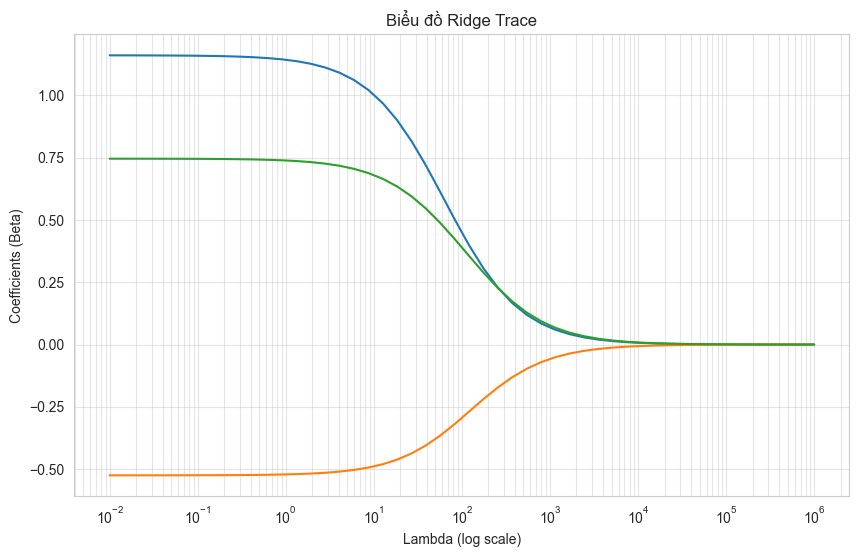

In [10]:
lambdas = np.logspace(-2, 6, 50)
plot_ridge_trace(X_with_const, y.tolist(), lambdas, title="Biểu đồ Ridge Trace")

### **Mục 7: Hàm residual_plots(X, y, beta_hat)**

Phân tích phần dư giúp kiểm tra các giả thiết của OLS:
1. **Residuals vs Fitted**: Kiểm tra tính tuyến tính và phương sai sai số không đổi.
2. **Normal Q-Q**: Kiểm tra giả thiết nhiễu tuân theo phân phối chuẩn.
3. **Scale-Location**: Kiểm tra tính đồng nhất của phương sai.
4. **Cook's Distance**: Phát hiện các điểm dữ liệu có ảnh hưởng lớn (outliers/leverage points).

In [ ]:
residual_plots(X.tolist(), y.tolist(), beta_hat)

### **Mục 8: Hàm kfold_cv(X, y, k)**

K-Fold Cross-Validation chia dữ liệu thành $k$ phần. Tại mỗi bước, $k-1$ phần dùng để huấn luyện và 1 phần dùng để đánh giá. Quá trình này giúp ước lượng khách quan hiệu năng của mô hình trên dữ liệu mới và lựa chọn siêu tham số $\lambda$ tối ưu cho Ridge.

In [ ]:
k = 5
search_lambdas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for lam in search_lambdas:
    mean_mse, _ = kfold_cv(X_with_const, y.tolist(), k, ridge_fit, seed=42, lam=lam)
    results.append({"Lambda": lam, "Mean MSE": mean_mse})

cv_df = pd.DataFrame(results)
print("Kết quả Cross-Validation cho mô hình Ridge:")
print(cv_df.to_string(index=False))

best_lambda = cv_df.loc[cv_df["Mean MSE"].idxmin(), "Lambda"]
print(f"\nGiá trị Lambda tối ưu: {best_lambda}")

### **Mục 9: Minh họa Định lý Gauss-Markov**

**Phát biểu định lý:** Trong các ước lượng tuyến tính và không chệch của $\beta$, ước lượng OLS $\hat{\beta}$ có phương sai nhỏ nhất. Tức là OLS là BLUE (Best Linear Unbiased Estimator).

**Mô phỏng Monte Carlo:**
1. Giữ nguyên ma trận thiết kế $X$.
2. Lặp $B$ lần: Sinh mới thành phần nhiễu chuẩn $\epsilon \sim \mathcal{N}(0, \sigma^2 I)$ để tạo vector mục tiêu $y = X\beta + \epsilon$.
3. Tính $\hat{\beta}_{OLS}$ cho toàn bộ dữ liệu.
4. Tính một ước lượng tuyến tính không chệch khác $\hat{\beta}_{Other}$ (ví dụ: OLS trên 70% dữ liệu ngẫu nhiên nhưng cố định vị trí).
5. So sánh trung bình (kiểm tra tính không chệch) và phương sai (kiểm tra tính tối ưu) của hai ước lượng.

--- So sánh cho hệ số beta_1 ---
Giá trị thực beta_1: 1.2
E[beta_hat_OLS]: 1.2010, Var: 0.0038
E[beta_hat_Alt]: 1.1989, Var: 0.0059


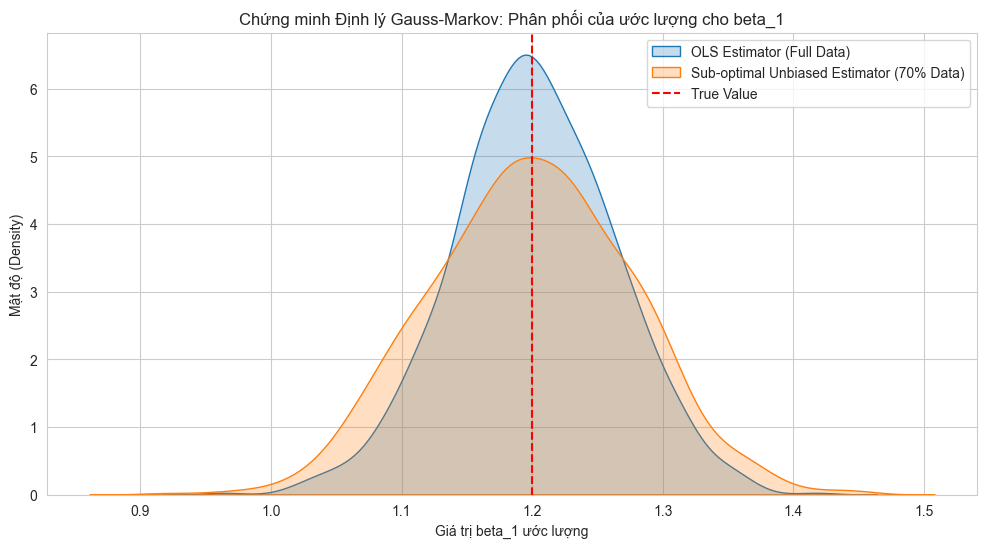

In [11]:
B = 1000
beta_ols_samples = []
beta_alt_samples = []

X_fixed = X
X_fixed_with_const = X_with_const
n_total = len(X_fixed)

subset_idx = np.random.choice(n_total, int(n_total * 0.7), replace=False)
X_subset = [X_fixed[i] for i in subset_idx]
X_subset_with_const = [X_fixed_with_const[i] for i in subset_idx]

for _ in range(B):
    epsilon = np.random.normal(0, 0.5, n_total)
    y_sim = true_beta[0] + X_fixed @ true_beta[1:] + epsilon
    
    b_ols, _ = ols_fit(X_fixed.tolist(), y_sim.tolist())
    beta_ols_samples.append(b_ols)
    
    y_subset = [y_sim[i] for i in subset_idx]
    b_alt, _ = ols_fit(X_subset, y_subset)
    beta_alt_samples.append(b_alt)

ols_array = np.array(beta_ols_samples)
alt_array = np.array(beta_alt_samples)

target_idx = 1
print(f"--- So sánh cho hệ số beta_{target_idx} ---")
print(f"Giá trị thực beta_{target_idx}: {true_beta[target_idx]}")
print(f"E[beta_hat_OLS]: {np.mean(ols_array[:, target_idx]):.4f}, Var: {np.var(ols_array[:, target_idx]):.4f}")
print(f"E[beta_hat_Alt]: {np.mean(alt_array[:, target_idx]):.4f}, Var: {np.var(alt_array[:, target_idx]):.4f}")

plt.figure(figsize=(12, 6))
sns.kdeplot(ols_array[:, target_idx], label='OLS Estimator (Full Data)', fill=True)
sns.kdeplot(alt_array[:, target_idx], label='Sub-optimal Unbiased Estimator (70% Data)', fill=True)
plt.axvline(true_beta[target_idx], color='red', linestyle='--', label='True Value')
plt.title(f'Chứng minh Định lý Gauss-Markov: Phân phối của ước lượng cho beta_{target_idx}')
plt.xlabel(f'Giá trị beta_{target_idx} ước lượng')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.show()